# About Dataset

link https://www.kaggle.com/datasets/omarmohammed70/how-education-drives-economic-growth


This dataset explores the relationship between education and economic performance across countries and continents. It combines key indicators such as literacy rates, physician density, GDP metrics, and unemployment to uncover patterns and insights into how human capital contributes to national prosperity.

## Imports

In [1]:
import os
import pandas as pd
import kagglehub
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("omarmohammed70/how-education-drives-economic-growth")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'how-education-drives-economic-growth' dataset.
Path to dataset files: /kaggle/input/how-education-drives-economic-growth


In [3]:
print(os.listdir(path))

['education-economy-data.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'education-economy-data.csv'))

## Explore The Data

In [5]:
df.head()

,Country,Literacy Rate,Physician Density,GDP (Current USD),GDP Growth (% Annual),GDP per Capita (Current USD),GDP per Capita Category,Unemployment Rate (%),Continent
0,Afghanistan,43.0,0.28,1.723305e+10,2.710887,415.707417,Very Low,13.991,Asia
1,Albania,98.1,1.20,2.354718e+10,3.936625,8575.171134,Mid,10.108,Europe
2,Algeria,81.4,1.72,2.476260e+11,4.100000,5364.027950,Low,11.701,Africa
3,Andorra,100.0,3.33,3.785067e+09,2.583555,46812.448450,High,3.700,Europe
4,Angola,71.1,0.21,8.482465e+10,1.001289,2308.159767,Low,14.537,Africa


In [6]:
df.isnull().sum()

,0
Country,0
Literacy Rate,0
Physician Density,0
GDP (Current USD),0
GDP Growth (% Annual),0
GDP per Capita (Current USD),0
GDP per Capita Category,0
Unemployment Rate (%),0
Continent,0


In [7]:
df.duplicated().sum()

np.int64(0)

## Preprocessing

In [8]:
df['GDP (Current USD)'] =df['GDP (Current USD)']/ 1e9

In [9]:
cat = ['Continent','Country']

dummy = pd.get_dummies(df[cat]).astype(int)
df = pd.concat([df,dummy],axis=1)

df = df.drop(cat,axis=1)

In [10]:
df['GDP per Capita Category'].value_counts()

,count
GDP per Capita Category,
Low,55
Very Low,41
Mid,40
High,35
Very High,20


In [11]:
df['GDP per Capita Category'] =  df['GDP per Capita Category'].astype('category').cat.codes

In [12]:
df.dtypes

,0
Literacy Rate,float64
Physician Density,float64
GDP (Current USD),float64
GDP Growth (% Annual),float64
GDP per Capita (Current USD),float64
...,...
Country_Venezuela,int64
Country_Vietnam,int64
Country_Yemen,int64
Country_Zambia,int64


## Visualization

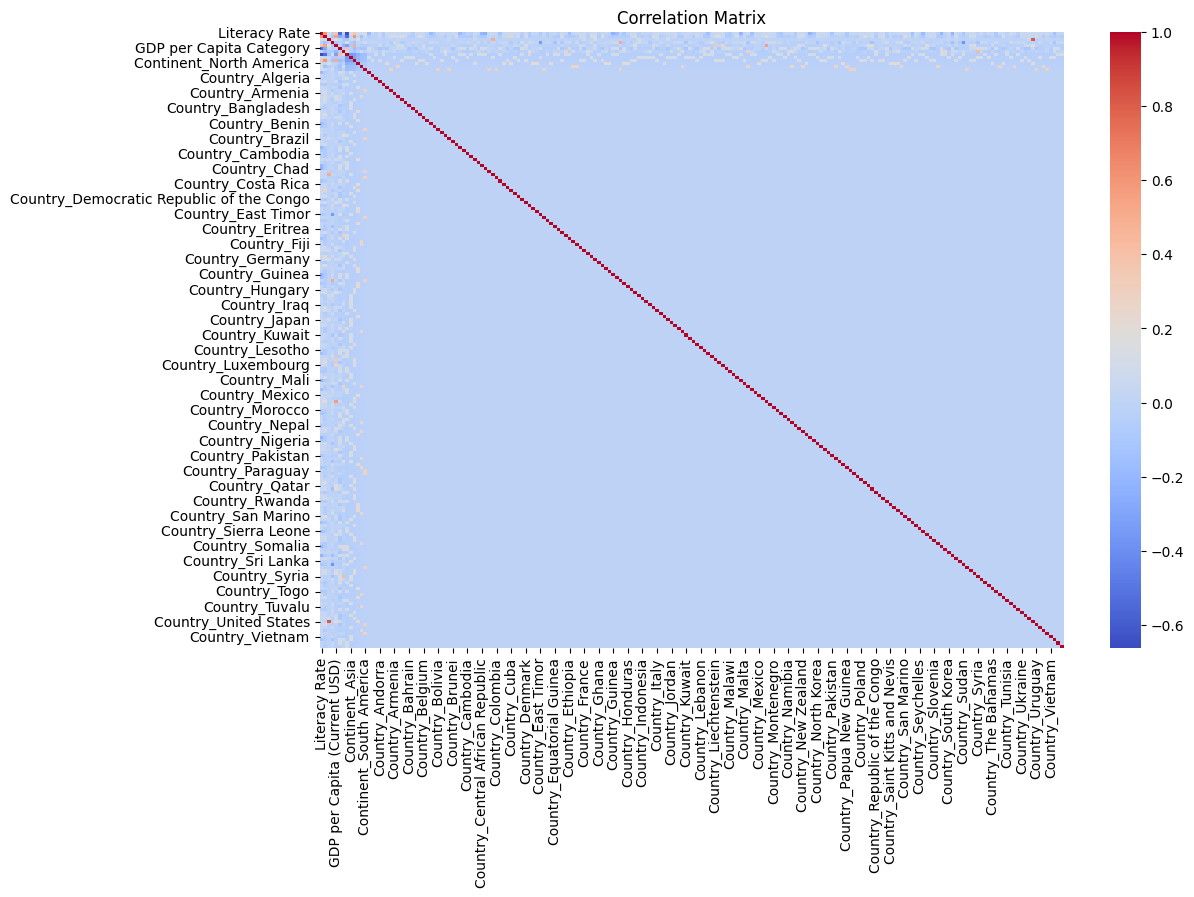

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation plot
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



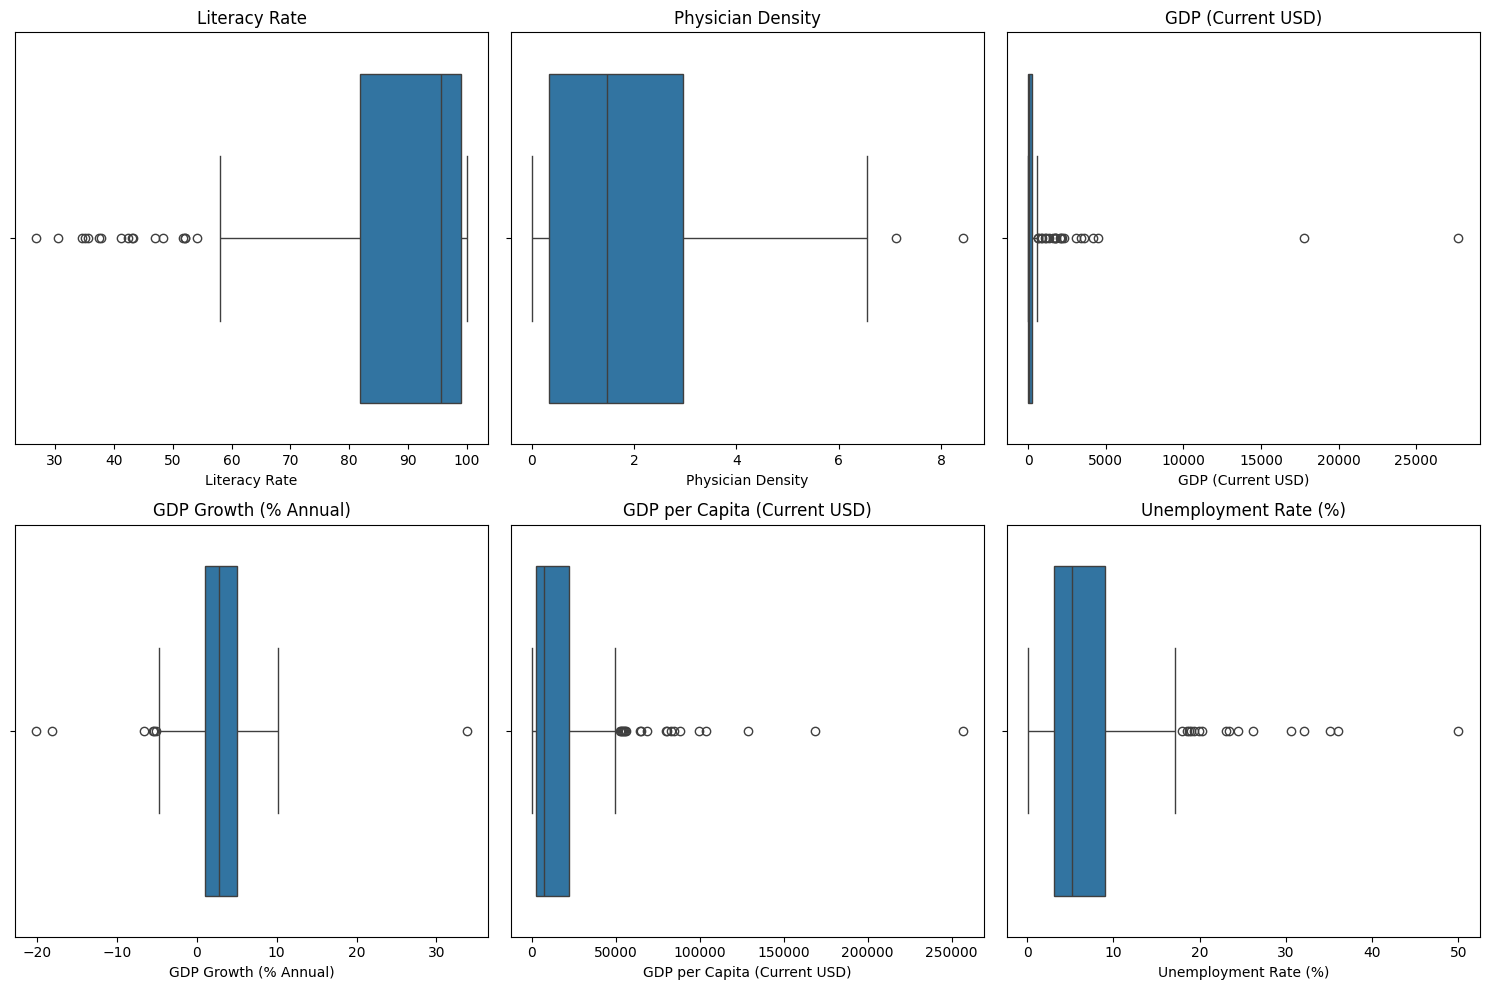

In [14]:
# Outlier plots (using box plots for a few relevant columns)
# Selecting a few numerical columns for outlier visualization
numerical_cols = ['Literacy Rate', 'Physician Density', 'GDP (Current USD)', 'GDP Growth (% Annual)', 'GDP per Capita (Current USD)', 'Unemployment Rate (%)']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Train Test Split

In [15]:
X = df.drop('GDP per Capita Category',axis=1)
y = df['GDP per Capita Category']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

                                                    X,y,
                                                    train_size=0.80,
                                                    random_state=42
)

In [17]:
RB = RobustScaler()

X_train = RB.fit_transform(X_train)
X_test = RB.transform(X_test)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [19]:
X.shape

(191, 203)

In [23]:
input = tf.keras.Input(shape=(X_train.shape[1],))
x = tf.keras.layers.Dense(64,activation='relu')(input)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(32,activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(12,activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(12,activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(5,activation='softmax')(x)

In [24]:
model = model = tf.keras.Model(inputs=input, outputs=output)
model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=32,
    batch_size=32,
    verbose=1
)

Epoch 1/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.2195 - loss: 1.6973 - val_accuracy: 0.2258 - val_loss: 1.5878
Epoch 2/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1858 - loss: 1.6749 - val_accuracy: 0.2258 - val_loss: 1.5818
Epoch 3/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2872 - loss: 1.6097 - val_accuracy: 0.2903 - val_loss: 1.5782
Epoch 4/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2415 - loss: 1.5987 - val_accuracy: 0.2581 - val_loss: 1.5745
Epoch 5/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2184 - loss: 1.6310 - val_accuracy: 0.2258 - val_loss: 1.5686
Epoch 6/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3244 - loss: 1.5985 - val_accuracy: 0.1935 - val_loss: 1.5616
Epoch 7/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2730 - loss: 1.5870 - val_accuracy: 0.2258 - val_loss: 1.5537
Epoch 8/32
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2860 - loss: 1.5624 - val_accuracy: 0.2258 - val_loss: 1.5420


## NN Model Results

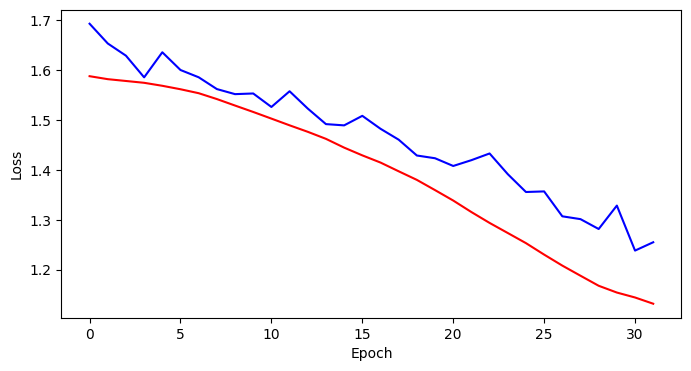

In [26]:

plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'], color='b')
plt.plot(history.history['val_loss'], color='r')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Accuracy: 0.5128


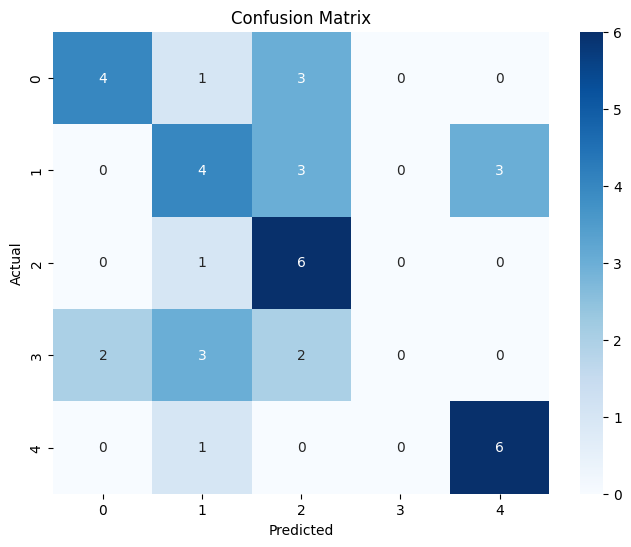

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         8
           1       0.40      0.40      0.40        10
           2       0.43      0.86      0.57         7
           3       0.00      0.00      0.00         7
           4       0.67      0.86      0.75         7

    accuracy                           0.51        39
   macro avg       0.43      0.52      0.46        39
weighted avg       0.44      0.51      0.46        39



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Predict on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Display classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

## ML Model Results

In [28]:
import xgboost as xgb

XGBoost Accuracy: 0.9487


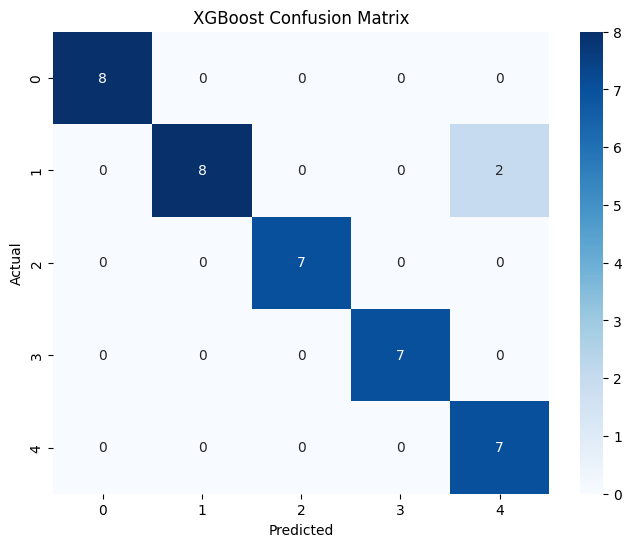

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.80      0.89        10
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         7
           4       0.78      1.00      0.88         7

    accuracy                           0.95        39
   macro avg       0.96      0.96      0.95        39
weighted avg       0.96      0.95      0.95        39



In [29]:
# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')

# Display confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

# Display classification report
print('XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))